In [3]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict,Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field


import operator
load_dotenv()

True

state : 

essay_text

cot_feedback

DOA_feedback

Language_feedback

final_feedback

individual_score

final / avg score


In [4]:
model = ChatGroq(
            model="llama-3.1-8b-instant",
            temperature=0.0,
            max_retries=2,
        
        )

In [5]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description="Detailed Feedback on the essay")
    score: int = Field(description="Score out of 10",ge=0,le=10)
    

In [6]:
structured_model = model.with_structured_output(EvaluationSchema)


In [7]:
eassy = """Human life has always been a mystery that thinkers, poets, and philosophers have tried to unravel through the ages. From the earliest civilizations to the modern world, the question of what constitutes a meaningful life has preoccupied the human mind. One of the most profound insights emerging from this reflection is the realization that life is best seen as a journey, not as a destination. To perceive life as a journey is to value growth over arrival, process over outcome, and experience over mere achievement. It is to live fully in the present moment, to embrace both joy and suffering as parts of an evolving process, and to recognize that the essence of life lies not in where we end up, but in how we travel through its varied paths. 

Across cultures and philosophies, this metaphor of life as a journey finds deep resonance. In the Indian spiritual tradition, life is often described as a yatra – a sacred pilgrimage. The Upanishads advocate the idea of “Neti Neti” – “not this, not this” – which signifies the endless quest for truth, where each realization leads to a deeper inquiry. The Buddha spoke of the “Middle Path,” not as a final point of arrival but as a continuous process of awareness and right action. In the Bhagavad Gita, Lord Krishna tells Arjuna that one has the right to perform their actions, but not to the fruits thereof. This timeless teaching captures the essence of journey-oriented living: action, sincerity, and detachment from rigid expectations. Modern thinkers have echoed this wisdom. Ralph Waldo Emerson wrote, “Life is a journey, not a destination,” while Arthur Ashe wrote that “Success is a journey, not a destination.” These reflections, both ancient and modern, underline that true fulfillment comes not from reaching an endpoint, but from constant evolution, learning, and inner growth. 

To view life as a destination, in contrast, is to see it as a race to be won, a fixed goal to be attained. It is to measure one’s worth by outcomes – success, wealth, power, or recognition – rather than by integrity, learning, or happiness. The danger of such a view is that it breeds anxiety, dissatisfaction, and burnout. When people fixate on results, they often neglect the process that gives life its texture and meaning. A destination-focused mindset can make one rigid, fearful of failure, and disconnected from the joy of living. Conversely, a journey-centric approach cultivates openness, curiosity, and resilience. It allows us to enjoy the process of creation, to find purpose in progress, and to accept setbacks as integral to growth. 

Consider the stages of life – childhood, adolescence, adulthood, and old age. Each stage has its unique joys and struggles. Childhood teaches innocence and wonder; youth teaches passion and exploration; adulthood teaches responsibility and balance; and old age teaches reflection and detachment. None of these stages is a “destination” in itself; they are all milestones in an ongoing journey. To see life as a journey, therefore, is to respect the flow of time and the lessons it brings. It helps us live more consciously, without undue regret for the past or obsession with the future. 

Philosophically, this view of life has deep implications. In Eastern thought, particularly in Hinduism and Buddhism, life is cyclical, not linear. The concept of samsara – the continuous cycle of birth, death, and rebirth – implies that life itself is an eternal journey of the soul toward higher consciousness. Similarly, in Jainism, the path to liberation (moksha) is not a single act of salvation but a sustained process of self-purification through right knowledge, faith, and conduct. In the Western tradition, thinkers like Albert Camus and Jean-Paul Sartre emphasized the importance of authenticity and the acceptance of life’s uncertainty. Camus’s idea of the “absurd” suggests that meaning is not handed to us; it must be created through our choices and perseverance. This echoes the idea that life’s purpose lies in the act of living itself, not in reaching a final, pre-defined endpoint.

In practical life, this philosophy manifests in many domains. Take education, for instance. Students who view learning as a journey derive joy from curiosity and continuous improvement, while those obsessed with grades or ranks often experience stress and disillusionment. True education, derived from the Latin educare, means “to draw out” the best in oneself. It is not about the mere accumulation of certificates, but about shaping character, intellect, and values. Similarly, in professional life, those who treat their careers as evolving journeys tend to find greater satisfaction and innovation. They adapt, learn, and grow, instead of being consumed by the pursuit of titles or monetary rewards. Success, in this sense, is not a fixed destination but a byproduct of purposeful effort and passion for one’s work. 

History and contemporary examples provide ample evidence of this philosophy in action. Dr. A.P.J. Abdul Kalam’s life is a shining illustration. Born in a modest family in Rameswaram, he faced numerous challenges but never saw success as a final point. His journey from a small-town boy to India’s “Missile Man” and later the President was characterized by humility, constant learning, and dedication. He famously said, “Excellence is a continuous process and not an accident.” For him, the joy lay in striving for progress, not merely in the achievements that came his way. 

Mahatma Gandhi’s life offers another powerful example. His journey from a timid lawyer in South Africa to the leader of India’s freedom movement was not defined by a single destination. Freedom for him was not just political independence but moral and social transformation. His experiments with truth, non-violence, and self-discipline were ongoing processes of self-refinement. Similarly, Nelson Mandela’s long struggle against apartheid, including 27 years in prison, was not just about attaining political office. His focus was on the journey of reconciliation, forgiveness, and building a just society. 

Even at the grassroots level, this philosophy finds resonance.  """

In [8]:
paragraphs = eassy.split('\n\n')

short_essay = '\n\n'.join(paragraphs[:5])  # Evaluate first 5 paragraphs

prompt = f"Evaluate the following essay excerpt and provide detailed feedback along with a score out of 10:\n\n{short_essay}"

structured_model.invoke(prompt)

EvaluationSchema(feedback='The essay provides a well-structured and thought-provoking exploration of the concept of life as a journey. The author effectively weaves together insights from various cultures and philosophies to create a compelling narrative. The writing is clear, concise, and engaging, making it accessible to a broad audience. However, some sentences could be tightened up for better flow, and a few paragraphs feel a bit disconnected from the rest of the essay. Overall, the author demonstrates a strong understanding of the topic and presents a persuasive argument. The only areas for improvement are minor and do not detract from the overall impact of the essay. Score: 9 out of 10.', score=9)

In [9]:
class UPSCState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

In [18]:
def evaluate_language(state: UPSCState) -> UPSCState:
    prompt = f"""Evaluate the language and grammar used in the following essay excerpt. 
    
Provide your response in JSON format with exactly two fields:
1. "feedback": A detailed string with your feedback on the language usage
2. "score": An integer between 0 and 10 representing the language quality

Essay: {state['essay']}

Respond with the JSON object only, no additional text."""
    result = structured_model.invoke(prompt)
    
    
    return {'language_feedback': result.feedback, 
            'individual_scores': [result.score]}

In [19]:
def evaluate_analysis(state: UPSCState) -> UPSCState:
    prompt = f"""Evaluate the depth and quality of analysis in the following essay excerpt.
    
Provide your response in JSON format with exactly two fields:
1. "feedback": A detailed string with your feedback on the analytical depth
2. "score": An integer between 0 and 10 representing the analysis quality

Essay: {state['essay']}

Respond with the JSON object only, no additional text."""
    result = structured_model.invoke(prompt)
    
    
    return {'analysis_feedback': result.feedback, 
            'individual_scores': [result.score]}

In [20]:
def evaluate_clarity(state: UPSCState) -> UPSCState:
    prompt = f"""Evaluate the clarity and organization of the following essay excerpt.
    
Provide your response in JSON format with exactly two fields:
1. "feedback": A detailed string with your feedback on clarity and organization
2. "score": An integer between 0 and 10 representing the clarity quality

Essay: {state['essay']}

Respond with the JSON object only, no additional text."""
    result = structured_model.invoke(prompt)
    
    
    return {'clarity_feedback': result.feedback, 
            'individual_scores': [result.score]}

In [21]:
def overall_feedback(state: UPSCState) -> UPSCState:
    # summary of the feedback
    prompt = f"Based on the following feedback, provide an overall evaluation of the essay, summarizing the strengths and weaknesses in language, analysis, and clarity:\n\nLanguage Feedback: {state['language_feedback']}\n\nAnalysis Feedback: {state['analysis_feedback']}\n\nClarity Feedback: {state['clarity_feedback']}"
    overall_feedback_result = model.invoke(prompt)
    
    # calculate average score from individual_scores list
    average_score = sum(state['individual_scores']) / len(state['individual_scores']) if state['individual_scores'] else 0
   
    # return overall feedback and average score
    overall_text = overall_feedback_result.content if hasattr(overall_feedback_result, 'content') else str(overall_feedback_result)
    
    return {'overall_feedback': overall_text,
            'avg_score': average_score}

In [22]:
graph = StateGraph(UPSCState)


graph.add_node('evaluate_language',evaluate_language)
graph.add_node('evaluate_analysis',evaluate_analysis)
graph.add_node('evaluate_clarity',evaluate_clarity)
graph.add_node('overall_feedback',overall_feedback)


#edges
graph.add_edge(START,'evaluate_language')
graph.add_edge(START,'evaluate_analysis')
graph.add_edge(START,'evaluate_clarity')

graph.add_edge('evaluate_language','overall_feedback')
graph.add_edge('evaluate_analysis','overall_feedback')
graph.add_edge('evaluate_clarity','overall_feedback')

graph.add_edge('overall_feedback',END)

workflow = graph.compile()



In [23]:
initial_state = {'essay': short_essay}   

workflow.invoke(initial_state)

{'essay': 'Human life has always been a mystery that thinkers, poets, and philosophers have tried to unravel through the ages. From the earliest civilizations to the modern world, the question of what constitutes a meaningful life has preoccupied the human mind. One of the most profound insights emerging from this reflection is the realization that life is best seen as a journey, not as a destination. To perceive life as a journey is to value growth over arrival, process over outcome, and experience over mere achievement. It is to live fully in the present moment, to embrace both joy and suffering as parts of an evolving process, and to recognize that the essence of life lies not in where we end up, but in how we travel through its varied paths. \n\nAcross cultures and philosophies, this metaphor of life as a journey finds deep resonance. In the Indian spiritual tradition, life is often described as a yatra – a sacred pilgrimage. The Upanishads advocate the idea of “Neti Neti” – “not t

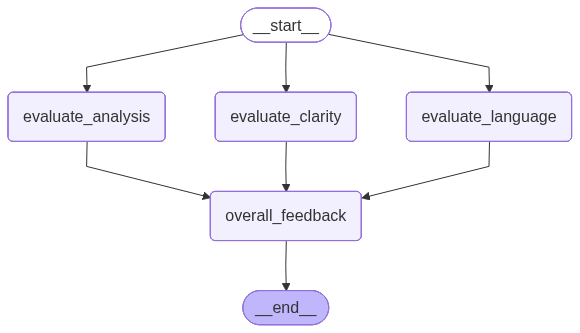

In [24]:
#visualize the graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())